Last Update: 05/07/2025, Author: Jemmy Dai

# **CLEAN Version: Prediction of DNI using (Physics Informed) Machine Learning**

Link to the clean version Google Colab/Jupyter Notebook:

https://colab.research.google.com/drive/126G7eb4lfvfldgOiS51W3iiFn--8gpRr?usp=sharing

This is a clean, simple, and user-friendly *downloaded* version. Please save a copy in your end before running the codes.

In [ ]:
# Basic Library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### **Objective**



Objective of this project is to use machine learning to predict Direct Normal Irradiance (DNI) based on Global Horizontal Irradiance (GHI) and other environmental factors like pressure, humidity, and temperature. Since GHI is easier to measure but DNI is more important for solar energy research, we aim to improve DNI predictions by using machine learning with guidance of previous models.


## **Load Dataset**

This dataset comes from NSRDB and covers the entire year from 2012 to 2023 in Bethlehem PA, with measurements taken every 30 minutes.

Useful **Attributes**:

Latitude: 40.65 \
Longitude: -75.38 \
Elevation: 106 meter \
Local Time Zone: -5 \
Temperature Units: C \
Pressure Units: mbar \
Relative Humidity Units: %

Updated: Add year 2011 data for testing compatibility


In [ ]:
# Load the original dataset from NSRDB (Year 2012 to 2023), which is uploaded to Google drive
path2021 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmZne271RQ9xUgEdY8Obi7ziNnLItkh4I3j0Lf5VCgAEw5sNLISePnhygDdeTfhwDcuJV2aHeZlxYb/pub?gid=1640194307&single=true&output=csv"
file3 = pd.read_csv(path2021, skiprows=2)
path2020 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTOM6gmivrhzapDo6rYZ4JHczS3TyrviHlxXLz3ykKX_TxgXfYC1XPkp5H5xV45EHHS7sKC1nLK3FiI/pub?gid=215456109&single=true&output=csv"
file4 = pd.read_csv(path2020, skiprows=2)
path2019 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQPeuZVc0alY-YJccyi8WxcgxmCEw24YE5_CKBStkiNc8PRNau6aTTHcdXfxQtntPf5kAeZXK-2uSoo/pub?gid=1714947388&single=true&output=csv"
file5 = pd.read_csv(path2019, skiprows=2)
path2018 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQVh7iGsp_CatnDRfpuDx6oCayjuSc9DdXtfC8OKfTmB_1cWL2PwYaf36LPG0vS9POHFLXexcQjDjoB/pub?gid=1512810097&single=true&output=csv"
file6 = pd.read_csv(path2018, skiprows=2)
path2017 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vS_Ytvf4h0uKy2QW8nNo-8RELfKjRseYDPg72ptlJs2BIwfVKVsEzzlNf0DDw2n_n-BMozfgRpnzyHw/pub?gid=113656081&single=true&output=csv"
file7 = pd.read_csv(path2017, skiprows=2)
path2016 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRfV_nFl3E_HggoR04W9p2fHuNK3wHUAZFQ_gjgHBDCT5HyjWCzNpLbl3sbAp4gT_91Mq0ybh-vD9G8/pub?output=csv"
file8 = pd.read_csv(path2016, skiprows=2)
path2015 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQ8XuIEjq8gm928owHsDtrIsVtWlnK_pzvkttEOtLilR8evkYnMjzvoLnfjr76GGufC6Hskvy2nspKB/pub?gid=985444057&single=true&output=csv"
file9 = pd.read_csv(path2015, skiprows=2)
path2014 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSiforBrv6YMsLMYGOEogK4rdVKz2sVBIGrUad2CMUDAwI5x3dD79KpfXOvpDAvni9uqPRya2IgesPz/pub?gid=1061926971&single=true&output=csv"
file10 = pd.read_csv(path2014, skiprows=2)
path2013 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTg4Gn7eN3p9f34gGqEw4Bn0OnPCfl5PAjSdOcxpjPM-T9NxT2Nrcn3lSixmuRshaDIoSisUW9osNjf/pub?gid=1373472215&single=true&output=csv"
file11 = pd.read_csv(path2013, skiprows=2)
path2012 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRPDtmsWHFIiqVYsjSD7Bu80DvP4DQZlt-1nT5CHyVzgXjMVHvy_1HjH00TglfyYhIB9yr9LfCSIqt_/pub?gid=1879251878&single=true&output=csv"
file12 = pd.read_csv(path2012, skiprows=2)

path2011 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRcbUjAhgPPekxOq4VpDEjGNXI5Gi21vjwCTA69KlfMRpDclblDLqJcRMNL4JAksb7kCESxHDpE4ghF/pub?gid=579415269&single=true&output=csv"
file13 = pd.read_csv(path2011, skiprows=2)


In [ ]:
# Combinee all files into a single DataFrame
files = [file13, file12, file11, file10, file9, file8, file7, file6, file5, file4, file3]
all_files = pd.concat(files, ignore_index=True)

# Display the first few rows of selected file
df = all_files.copy()
print(f"File shape: {df.shape}")
df.head()

File shape: (192720, 46)


,Year,Month,Day,Hour,Minute,DNI,DHI,GHI,Dew Point,Temperature,...,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45
0,2011,1,1,0,0,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,1,1,0,30,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,1,1,1,0,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,1,1,1,30,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,1,1,2,0,0,0,0,-0.2,-0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Total minutes** represent the number of minutes that have passed since the start date of the date (January 1, 2012 at 0:00 am). This function below converts arrays of Month, Day, Hour, and Minute into total minutes from the start of the year.

In [ ]:
# Compute total minutes from the first date of the dataset
def calculate_total_minutes(years, months, days, hours, minutes):

    # Define the number of days in each month (no leap years)
    days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    cumulative_days = np.cumsum(days_in_month) - days_in_month
    total_minutes = np.zeros(len(years), dtype=int)

    for i, (year, month, day, hour, minute) in enumerate(zip(years, months, days, hours, minutes)):

        min_year = years.min()
        total_days_before_year = (year - min_year) * 365
        days_before_month = cumulative_days[month - 1]
        total_minutes[i] = ((total_days_before_year + days_before_month + (day - 1)) * 24 * 60) + (hour * 60) + minute

    return total_minutes

In [ ]:
# Extract the months, days, hours, minutes from original data
years = df['Year'].values
months = df['Month'].values
days = df['Day'].values
hours = df['Hour'].values
minutes = df['Minute'].values

total_minutes_array = calculate_total_minutes(years, months, days, hours, minutes)
print("Number of points:", len(total_minutes_array))
print("Min and Max:", total_minutes_array.min(), total_minutes_array.max())
total_minutes_array

Number of points: 192720
Min and Max: 0 5781570


array([      0,      30,      60, ..., 5781510, 5781540, 5781570])

In [ ]:
# Calculator: Compute the corresponding date from Total mintute (No need to run)
from datetime import datetime, timedelta

# Define start date and total minutes
start_date = datetime(2023, 1, 1, 0, 0)
total_minutes = 430000

converted_datetime = start_date + timedelta(minutes=total_minutes)
converted_datetime

datetime.datetime(2023, 10, 26, 14, 40)

**Day of year** is a number that tells you which day it is out of all the days in the year, starting from January 1 as day 1.

In [ ]:
# Convert a ARRAY of date and time to the day of the year
def datetime_to_day_of_year(month, day, hour=0, minute=0, year=2024):
    dates = pd.to_datetime({'year': year, 'month': month, 'day': day, 'hour': hour, 'minute': minute})
    return dates.dt.dayofyear.values

# Example usage
day_of_year = datetime_to_day_of_year(months, days)
print("Number of points:", len(day_of_year))
day_of_year

Number of points: 192720


array([  1,   1,   1, ..., 366, 366, 366], dtype=int32)

In [ ]:
# Extract the temperature, pressure, and relative humidity from original data
valid_mask = ~df[['Temperature', 'Pressure', 'Relative Humidity']].isnull().any(axis=1)
minutes = total_minutes_array[valid_mask]
temperatures = df['Temperature'][valid_mask]
pressures = df['Pressure'][valid_mask]
humidities = df['Relative Humidity'][valid_mask]
dew_points = df['Dew Point'][valid_mask]

In [ ]:
# Calculate dew point (°C) for scalar or array inputs
def dew_point_calculator(temp_c, rel_humidity):
    a = 17.27
    b = 237.7  # °C

    # ensure NumPy arrays
    T = np.asarray(temp_c, dtype=float)
    RH = np.asarray(rel_humidity, dtype=float) /100.0

    gamma = (a * T) / (b + T) + np.log(RH)
    dew = (b * gamma) / (a - gamma)
    return dew

# Example usage with arrays
temps = 18.1
rhs   = 44.45
dps   = dew_point_calculator(temps, rhs)
print("Dew points:", dps)

Dew points: 5.7975892007765735


In [ ]:
# Extract DNI, DHI, and GHI from the original data
dni = df['DNI']
dhi = df['DHI']
ghi = df['GHI']

## **Basic Calculations**

### **Zenith Angle**

First, we must install Astral, a python package for calculating the times of various aspects of the sun and moon. \
Astral Package Website: https://astral.readthedocs.io/en/latest/package.html

In [ ]:
pip install astral

In [ ]:
from astral import Observer
from astral.sun import zenith, elevation
from datetime import datetime, timezone, timedelta

In [ ]:
# Calculate the solar zenith angle for a given date, time, and location. (No need to run)
def calculate_solar_zenith_single(local_time, tz_offset, latitude, longitude, elevation=0):

    # Define the observer's location, local datetime (and convert to UTC)
    observer = Observer(latitude=latitude, longitude=longitude, elevation=elevation)
    local_time = datetime(year, month, day, hour, minute)
    utc_time = local_time.replace(tzinfo=timezone(timedelta(hours=tz_offset))).astimezone(timezone.utc)

    # Compute the solar zenith angle
    zenith_angle = zenith(observer, utc_time, with_refraction=True)

    return zenith_angle

# Example Usage
year = 2023
month = 4
day = 16
hour = 15
minute = 30
tz_offset = -5

latitude = 40.65
longitude = -75.38
elevat = 106

local_time = datetime(year, month, day, hour, minute)
zenith_angle = calculate_solar_zenith_single(local_time, tz_offset, latitude, longitude, elevat)

print(f"Solar zenith angle on {local_time} is {zenith_angle:.2f} degrees")

Solar zenith angle on 2023-04-16 15:30:00 is 54.96 degrees


In [ ]:
# Computes solar zenith angles for a specific time range.
def calculate_solar_zenith(start_minute, end_minute, years, months, days, hours, minutes, tz_offset, latitude, longitude, elevation):

    observer = Observer(latitude=latitude, longitude=longitude, elevation=elevation)
    total_minutes_array = calculate_total_minutes(years, months, days, hours, minutes)

    # Filter data based on the specified time range
    mask = (total_minutes_array >= start_minute) & (total_minutes_array <= end_minute)
    filtered_minutes = total_minutes_array[mask]

    # Compute zenith angles
    filtered_timestamps = [datetime(y, m, d, h, mi) - timedelta(hours=tz_offset)
                           for y, m, d, h, mi in zip(years[mask], months[mask], days[mask], hours[mask], minutes[mask])]
    filtered_zenith_angles = np.array([zenith(observer, ts) for ts in filtered_timestamps])

    return filtered_zenith_angles, filtered_minutes

In [ ]:
# Example usage
start_minute = 0
end_minute = 50000

years = df['Year']
months = df['Month']
days = df['Day']
hours = df['Hour']
minutes = df['Minute']

# Compute the zenith angles for all available years
filtered_zenith_angles, filtered_minutes = calculate_solar_zenith(
    start_minute, end_minute, years, months, days, hours,
    minutes,tz_offset=-5, latitude=40.65, longitude=-75.38, elevation=106)

# Calculate cosine of the filtered zenith angle
cos_zenith = np.cos(np.radians(filtered_zenith_angles))


### **Extraterrestrial Irradiance**

**Extraterrestrial Solar Irradiance** ($ \text{DNI}_\text{extra} $) is the instantaneous solar irradiance (in W/m²) outside Earth's atmosphere, on a surface perpendicular to the Sun's rays.

$$
\text{DNI}_\text{extra} = G_\text{sc} \cdot \left(1 + 0.033 \cdot \cos\left(\frac{360 \cdot n}{365}\right)\right)
$$

Where:
- $ G_\text{sc} $: Solar constant (default $1366.1 W/m²$)
- $ n $: Day of the year

**Horizontal extraterrestrial irradiance** accounts for the tilt between the Sun’s rays and a flat (horizontal) surface.

$$
G_0 = DNI_{\text{extra}} \cdot \cos(\theta_z)
$$

Where:
- $ G_0 $: Extraterrestrial irradiance on a horizontal surface.
- $ \theta_z $: Solar zenith angle

We must install pvlib python library, a community developed toolbox that provides a set of functions and classes for simulating the performance of photovoltaic energy systems. This allows future models using these library.

In [ ]:
!pip install pvlib

import pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 87.4 MB/s eta 0:00:00


In [ ]:
# Calculate the extraterrestrial radiation for a given date
def calculate_extraterrestrial_radiation(local_time, tz_offset=-5, method='spencer', solar_constant=1366.1, epoch_year=2014):

    # Convert local time to UTC
    utc_time = local_time.replace(tzinfo=timezone(timedelta(hours=tz_offset))).astimezone(timezone.utc)

    # Use pvlib to calculate extraterrestrial radiation
    dni_extra = pvlib.irradiance.get_extra_radiation(
        utc_time,
        method=method,
        solar_constant=solar_constant,
        epoch_year=epoch_year
    )

    return dni_extra

# Example usage
year = 2023
month = 4
day = 16
hour = 15
minute = 30
tz_offset = -5

local_time = datetime(year, month, day, hour, minute)
dni_extra_ex = calculate_extraterrestrial_radiation(local_time, tz_offset)

print(f"Solar Extraterrestrial Irradiation on {local_time} is {dni_extra_ex:.2f} W/m²")

Solar Extraterrestrial Irradiation on 2023-04-16 15:30:00 is 1356.07 W/m²


In [ ]:
def calculate_extraterrestrial_radiation_range(start_minute, end_minute, years, months, days, hours, minutes, tz_offset=-5):
    # Filter data for specified time range
    total_minutes_array = calculate_total_minutes(years, months, days, hours, minutes)
    mask = (total_minutes_array >= start_minute) & (total_minutes_array <= end_minute)
    filtered_minutes = total_minutes_array[mask]

    # Create datetime objects in UTC
    filtered_datetimes_utc = [
        datetime(y, m, d, h, mi).replace(tzinfo=timezone(timedelta(hours=tz_offset))).astimezone(timezone.utc)
        for y, m, d, h, mi in zip(years[mask], months[mask], days[mask], hours[mask], minutes[mask])
    ]

    # Calculate extraterrestrial irradiation
    filtered_datetimes_index = pd.DatetimeIndex(filtered_datetimes_utc)
    dni_extra = pvlib.irradiance.get_extra_radiation(filtered_datetimes_index)

    return dni_extra.values, filtered_minutes

### **Clearness Index**

**Clearness index** $(K_t)$ is the fraction of the solar radiation that is transmitted through the atmosphere to strike the surface of the Earth (dimensionless).

$$  K_{t} = \frac{GHI}{G_{0}}  $$

In [ ]:
# Calculate Clearness Index
def calculate_kt(start_minute, end_minute, years, months, days, hours, minutes, tz_offset=0):
    # Filter data for specified time range
    total_minutes_array = calculate_total_minutes(years, months, days, hours, minutes)
    mask = (total_minutes_array >= start_minute) & (total_minutes_array <= end_minute)
    filtered_minutes = total_minutes_array[mask]
    filtered_ghi = ghi[mask]

    # Recalculate extraterrestrial radiation and G0 for the filtered data
    dni_extra_filtered, _ = calculate_extraterrestrial_radiation_range(
        start_minute, end_minute, years, months, days, hours, minutes, tz_offset=tz_offset
    )
    filtered_zenith_angles, _ = calculate_solar_zenith(
        start_minute, end_minute, years, months, days, hours, minutes,
        tz_offset=-5, latitude=40.65, longitude=-75.38, elevation=106
    )
    cos_zenith_filtered = np.cos(np.radians(filtered_zenith_angles))
    G0_filtered = dni_extra_filtered * cos_zenith_filtered
    G0_filtered[filtered_zenith_angles > 90] = 0

    # Calculate Kt
    kt = filtered_ghi / G0_filtered
    kt[np.isinf(kt)] = 0  # Replace infinite
    kt[np.isnan(kt)] = 0 # Replace NaN
    kt = np.clip(kt, 0, 1) # cap everything to the range 0 – 1

    return kt, filtered_minutes

In [ ]:
# Calculate clearness index (Kt) for all data
def calculate_kt_for_df(df, theta_z, dni_extra):
    # Calculate cos(zenith) and extraterrestrial horizontal irradiance
    cos_zenith = np.cos(np.radians(theta_z))
    G0 = dni_extra * cos_zenith
    G0[theta_z > 90] = 0

    # Calculate clearness index (Kt)
    kt = df['GHI'].values / G0
    kt[np.isinf(kt)] = 0  # Replace infinite values
    kt[np.isnan(kt)] = 0  # Replace NaN values
    kt = np.clip(kt, 0, 1)  # Clip to valid range [0, 1]

    return kt

In [ ]:
# Extract inputs from test file
test_file = file3.copy()

ghi_test = test_file['GHI'].values
y_test = test_file['DNI'].values
year_test = test_file['Year'].values
month_test = test_file['Month'].values
day_test = test_file['Day'].values
hour_test = test_file['Hour'].values
minute_test = test_file['Minute'].values
temperature_test = test_file['Temperature'].values
pressure_test = test_file['Pressure'].values
humidity_test = test_file['Relative Humidity'].values
dew_point_test = test_file['Dew Point'].values

total_minutes_test = calculate_total_minutes(year_test, month_test, day_test, hour_test, minute_test)

# Compute the basic calculation for test file
zenith_angles_test, total_minutes_test = calculate_solar_zenith(
    0, total_minutes_test.max(),
    year_test, month_test, day_test, hour_test, minute_test,
    tz_offset=-5, latitude=40.65, longitude=-75.38, elevation=106
)
dni_extra_test, total_minutes_test = calculate_extraterrestrial_radiation_range(
    0, total_minutes_test.max(),
    year_test, month_test, day_test, hour_test, minute_test,
    tz_offset=-5
)

cos_zenith_test = np.cos(np.radians(zenith_angles_test))

total_minutes_test = total_minutes_test - total_minutes_test.min()
day_of_year_test = datetime_to_day_of_year(month_test, day_test)

print("Number of points in test file:", len(y_test))

Number of points in test file: 17520


## **Machine Learning (ML)**

### **Set up Environment**

Let us load the machine learning library first.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import StandardScaler

Split the training data into three categories:

1. Overcast $(K_t ≤ 0.35)$
2. Partly cloudy $(0.35 < K_t ≤ 0.70)$
3. Clear sky $(K_t > 0.70)$

In [ ]:
# Calculate theta_z and G0 for unfiltered data again
theta_z, total_minutes = calculate_solar_zenith(
    0, total_minutes_array.max(), years, months, days, hours, minutes,
    tz_offset=-5, latitude=40.65, longitude=-75.38, elevation=106
)

dni_extra_all, total_minutes = calculate_extraterrestrial_radiation_range(
    0, total_minutes_array.max(),
    years, months, days, hours, minutes,
    tz_offset=-5
)

cos_zenith = np.cos(np.radians(theta_z))
G0_all = dni_extra_all * cos_zenith
G0_all[theta_z > 90] = 0  # Set G0 to 0 for zenith angles > 90

# Calculate clearness index (Kt) for all data
kt_all = np.zeros_like(G0_all)
valid_G0 = G0_all > 0
kt_all[valid_G0] = df['GHI'].values[valid_G0] / G0_all[valid_G0]  # Only calculate where G0 > 0
kt_all = np.clip(kt_all, 0, 1)  # Clip to valid range [0, 1]
df['Kt'] = kt_all
daytime_mask = theta_z < 90

# Separate the Test File
test_file = file3.copy()
n_test = len(test_file)

# Calculate Kt for test data
test_G0 = G0_all[-n_test:]
test_kt = np.zeros_like(test_G0)
valid_test_G0 = test_G0 > 0
test_kt[valid_test_G0] = test_file['GHI'].values[valid_test_G0] / test_G0[valid_test_G0]
test_kt = np.clip(test_kt, 0, 1)
test_file['Kt'] = test_kt

# Apply daytime mask to test data
test_daytime_mask = daytime_mask[-n_test:]
test_file['is_daytime'] = test_daytime_mask

# Prepare test inputs with Kt added (daytime only)
X_test = test_file[test_daytime_mask][['GHI', 'Temperature', 'Dew Point', 'Pressure', 'Kt']].copy()
X_test['Solar Cos Zenith Angle'] = np.cos(np.radians(theta_z[-n_test:][test_daytime_mask]))
X_test['G0'] = G0_all[-n_test:][test_daytime_mask]
y_test = test_file[test_daytime_mask]['DNI']

remaining_files = all_files.drop(file3.index).reset_index(drop=True)

# Calculate Kt for remaining data
remaining_G0 = G0_all[:-n_test]
remaining_kt = np.zeros_like(remaining_G0)
valid_remaining_G0 = remaining_G0 > 0
remaining_kt[valid_remaining_G0] = remaining_files['GHI'].values[valid_remaining_G0] / remaining_G0[valid_remaining_G0]
remaining_kt = np.clip(remaining_kt, 0, 1)
remaining_files['Kt'] = remaining_kt

remaining_daytime_mask = daytime_mask[:-n_test]
remaining_files['is_daytime'] = remaining_daytime_mask

# Add Kt to remaining features (daytime only)
X_remaining = remaining_files[remaining_daytime_mask][['GHI', 'Temperature', 'Dew Point', 'Pressure', 'Kt']].copy()
X_remaining['Solar Cos Zenith Angle'] = np.cos(np.radians(theta_z[:-n_test][remaining_daytime_mask]))
X_remaining['G0'] = G0_all[:-n_test][remaining_daytime_mask]
y_remaining = remaining_files[remaining_daytime_mask]['DNI']

# Split data by sky condition before train/test split
# Overcast: Kt <= 0.35
overcast_mask = X_remaining['Kt'] <= 0.35
X_overcast = X_remaining[overcast_mask].copy()
y_overcast = y_remaining[overcast_mask.values]

# Partly cloudy: 0.35 < Kt <= 0.70  (MODIFIED: Changed from 0.75 to 0.70)
partly_cloudy_mask = (X_remaining['Kt'] > 0.35) & (X_remaining['Kt'] <= 0.70)
X_partly_cloudy = X_remaining[partly_cloudy_mask].copy()
y_partly_cloudy = y_remaining[partly_cloudy_mask.values]

# Clear sky: Kt > 0.70  (MODIFIED: Changed from 0.75 to 0.70)
clear_sky_mask = X_remaining['Kt'] > 0.70
X_clear_sky = X_remaining[clear_sky_mask].copy()
y_clear_sky = y_remaining[clear_sky_mask.values]

# Print data distribution
print(f"Overcast data points: {len(X_overcast)}")
print(f"Partly cloudy data points: {len(X_partly_cloudy)}")
print(f"Clear sky data points: {len(X_clear_sky)}")

Overcast data points: 30690
Partly cloudy data points: 38919
Clear sky data points: 19263


In [ ]:
# Split each sky condition dataset into training and validation sets
X_train_overcast, X_val_overcast, y_train_overcast, y_val_overcast = train_test_split(
    X_overcast, y_overcast, test_size=0.2, random_state=42)

X_train_partly_cloudy, X_val_partly_cloudy, y_train_partly_cloudy, y_val_partly_cloudy = train_test_split(
    X_partly_cloudy, y_partly_cloudy, test_size=0.2, random_state=42)

X_train_clear_sky, X_val_clear_sky, y_train_clear_sky, y_val_clear_sky = train_test_split(
    X_clear_sky, y_clear_sky, test_size=0.2, random_state=42)

# Also maintain the original train/val split for comparison
X_train, X_val, y_train, y_val = train_test_split(X_remaining, y_remaining, test_size=0.2, random_state=42)

# Create scalers for each dataset
scaler = StandardScaler()
scaler_overcast = StandardScaler()
scaler_partly_cloudy = StandardScaler()
scaler_clear_sky = StandardScaler()

# Scale the datasets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_overcast_scaled = scaler_overcast.fit_transform(X_train_overcast)
X_val_overcast_scaled = scaler_overcast.transform(X_val_overcast)

X_train_partly_cloudy_scaled = scaler_partly_cloudy.fit_transform(X_train_partly_cloudy)
X_val_partly_cloudy_scaled = scaler_partly_cloudy.transform(X_val_partly_cloudy)

X_train_clear_sky_scaled = scaler_clear_sky.fit_transform(X_train_clear_sky)
X_val_clear_sky_scaled = scaler_clear_sky.transform(X_val_clear_sky)

# Check shapes
print("X_train.shape", X_train.shape)
print("X_val.shape", X_val.shape)
print("X_test.shape", X_test.shape)

print("X_train_overcast.shape", X_train_overcast.shape)
print("X_train_partly_cloudy.shape", X_train_partly_cloudy.shape)
print("X_train_clear_sky.shape", X_train_clear_sky.shape)


X_train.shape (71097, 7)
X_val.shape (17775, 7)
X_test.shape (8889, 7)
X_train_overcast.shape (24552, 7)
X_train_partly_cloudy.shape (31135, 7)
X_train_clear_sky.shape (15410, 7)


In [ ]:
def build_and_train_model(X_train, y_train, X_val, y_val, model_name=""):
    # Build model
    model = keras.Sequential([
        # Input layer with batch normalization
        layers.Dense(128, input_shape=(X_train.shape[1],)),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # Hidden layers
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # Output layer
        layers.Dense(1)
    ])

    # Compile
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mean_absolute_error', 'mean_squared_error']
    )

    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f'best_model_{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    return model, history


### **Start ML**

Warning: This code (machine learning) might take long time to run.

In [ ]:
# Train models for each sky condition
print("Training overcast model...")
model_overcast, history_overcast = build_and_train_model(
    X_train_overcast_scaled, y_train_overcast,
    X_val_overcast_scaled, y_val_overcast,
    model_name="overcast"
)

print("Training partly cloudy model...")
model_partly_cloudy, history_partly_cloudy = build_and_train_model(
    X_train_partly_cloudy_scaled, y_train_partly_cloudy,
    X_val_partly_cloudy_scaled, y_val_partly_cloudy,
    model_name="partly_cloudy"
)

print("Training clear sky model...")
model_clear_sky, history_clear_sky = build_and_train_model(
    X_train_clear_sky_scaled, y_train_clear_sky,
    X_val_clear_sky_scaled, y_val_clear_sky,
    model_name="clear_sky"
)

Training overcast model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 330.5481 - mean_absolute_error: 6.3235 - mean_squared_error: 330.5481
Epoch 1: val_loss improved from None to 350.82901, saving model to best_model_overcast.keras

Epoch 1: finished saving model to best_model_overcast.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 340.2422 - mean_absolute_error: 6.4662 - mean_squared_error: 340.2422 - val_loss: 350.8290 - val_mean_absolute_error: 6.8978 - val_mean_squared_error: 350.8290
Epoch 2/100
763/768 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 318.7416 - mean_absolute_error: 6.9818 - mean_squared_error: 318.7416
Epoch 2: val_loss improved from 350.82901 to 346.52200, saving model to best_model_overcast.keras

Epoch 2: finished saving model to best_model_overcast.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 314.8883 - mean_absolute_error: 6.8811 - mean_squared_error: 314.8883 - val_loss: 346.5220 - val_mean_absolute_error: 6.9883 - val_mean_squared_error: 346.5220
Epoch 3

In [ ]:
# Predict using the trained neural network
def constrain_dni_predictions(y_pred, ghi, cos_theta_z):
    # Apply constraints: 0 <= DNI <= GHI / cos(theta_z)
    upper_limit = np.where(cos_theta_z > 0, ghi / cos_theta_z, np.inf)
    y_pred_constrained = np.clip(y_pred, 0, upper_limit)
    return y_pred_constrained

def predict_by_sky_condition(X_test, kt_test):

    # Create masks for each sky condition with updated thresholds
    overcast_mask = kt_test <= 0.35
    partly_cloudy_mask = (kt_test > 0.35) & (kt_test <= 0.70)
    clear_sky_mask = kt_test > 0.70

    # Initialize predictions array
    y_pred = np.zeros(len(X_test))

    # Predict using the appropriate model for each sky condition
    if np.any(overcast_mask):
        X_test_overcast = X_test[overcast_mask]
        X_test_overcast_scaled = scaler_overcast.transform(X_test_overcast)
        y_pred[overcast_mask] = model_overcast.predict(X_test_overcast_scaled).flatten()

    if np.any(partly_cloudy_mask):
        X_test_partly_cloudy = X_test[partly_cloudy_mask]
        X_test_partly_cloudy_scaled = scaler_partly_cloudy.transform(X_test_partly_cloudy)
        y_pred[partly_cloudy_mask] = model_partly_cloudy.predict(X_test_partly_cloudy_scaled).flatten()

    if np.any(clear_sky_mask):
        X_test_clear_sky = X_test[clear_sky_mask]
        X_test_clear_sky_scaled = scaler_clear_sky.transform(X_test_clear_sky)
        y_pred[clear_sky_mask] = model_clear_sky.predict(X_test_clear_sky_scaled).flatten()

    # Apply physical constraints
    y_pred = constrain_dni_predictions(y_pred, X_test['GHI'].values, X_test['Solar Cos Zenith Angle'].values)

    return y_pred

# Make predictions using the sky condition-based models
y_pred_sky_models = predict_by_sky_condition(X_test, X_test['Kt'])
y_pred_sky_models = constrain_dni_predictions(y_pred_sky_models, X_test['GHI'].values, X_test['Solar Cos Zenith Angle'].values)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


### **Evaluate Result**

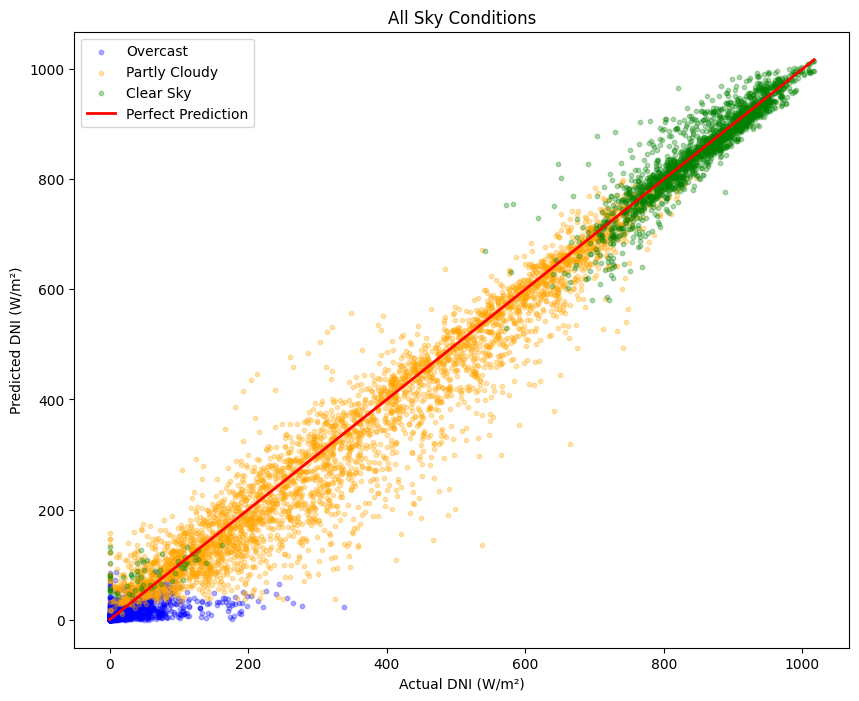

In [ ]:
# Create a dedicated plot for All Sky Conditions only
plt.figure(figsize=(10, 8))

# Get masks for different sky conditions
overcast_mask = X_test['Kt'] <= 0.35
partly_cloudy_mask = (X_test['Kt'] > 0.35) & (X_test['Kt'] <= 0.70)
clear_sky_mask = X_test['Kt'] > 0.70

# Plot for All Conditions (combined)
plt.scatter(y_test[overcast_mask], y_pred_sky_models[overcast_mask], alpha=0.3, s=10, c='blue', label='Overcast')
plt.scatter(y_test[partly_cloudy_mask], y_pred_sky_models[partly_cloudy_mask], alpha=0.3, s=10, c='orange', label='Partly Cloudy')
plt.scatter(y_test[clear_sky_mask], y_pred_sky_models[clear_sky_mask], alpha=0.3, s=10, c='green', label='Clear Sky')
plt.plot([0, max(y_test)], [0, max(y_test)], linewidth=2, label='Perfect Prediction', c='red')
plt.xlabel('Actual DNI (W/m²)')
plt.ylabel('Predicted DNI (W/m²)')
plt.title('All Sky Conditions')
plt.legend()

# Save the figure
plt.savefig('all_sky_conditions_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

R-Squared (R²):
$$ R^2 = 1 - \frac{\sum (t_i - p_i)^2}{\sum (t_i - \bar{t})^2}  $$

Mean Absolute Error (MAE):
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |t_i - p_i|$$


Mean Square Error (MSE):
$$ MSE = \dfrac{1}{n} \sum^n_{i=1} (t_i - p_i)^2 $$

Root Mean Squared Error (RMSE):
$$RMSE = \sqrt{MSE} $$

Where $t_i$ and $p_i$ are actual and predicted DNI respectively

In [ ]:
# Predict using the appropriate model for each sky condition
def predict_by_sky_condition(X_test, kt_test):

    # Create masks for each sky condition with updated thresholds
    overcast_mask = kt_test <= 0.35
    partly_cloudy_mask = (kt_test > 0.35) & (kt_test <= 0.70)
    clear_sky_mask = kt_test > 0.70
    y_pred = np.zeros(len(X_test))

    if np.any(overcast_mask):
        X_test_overcast = X_test[overcast_mask]
        X_test_overcast_scaled = scaler_overcast.transform(X_test_overcast)
        y_pred[overcast_mask] = model_overcast.predict(X_test_overcast_scaled).flatten()

    if np.any(partly_cloudy_mask):
        X_test_partly_cloudy = X_test[partly_cloudy_mask]
        X_test_partly_cloudy_scaled = scaler_partly_cloudy.transform(X_test_partly_cloudy)
        y_pred[partly_cloudy_mask] = model_partly_cloudy.predict(X_test_partly_cloudy_scaled).flatten()

    if np.any(clear_sky_mask):
        X_test_clear_sky = X_test[clear_sky_mask]
        X_test_clear_sky_scaled = scaler_clear_sky.transform(X_test_clear_sky)
        y_pred[clear_sky_mask] = model_clear_sky.predict(X_test_clear_sky_scaled).flatten()

    # Apply physical constraints
    y_pred = constrain_dni_predictions(y_pred, X_test['GHI'].values, X_test['Solar Cos Zenith Angle'].values)

    return y_pred

# Make predictions using the sky condition-based models
y_pred_sky_models = predict_by_sky_condition(X_test, X_test['Kt'])

# Updated evaluation function
def evaluate_by_sky_condition(y_test, y_pred, kt):
    # Predict using the appropriate model for each sky condition
    overcast_mask = kt <= 0.35
    partly_cloudy_mask = (kt > 0.35) & (kt <= 0.70)
    clear_sky_mask = kt > 0.70

    sky_conditions = {
        'All': np.ones_like(kt, dtype=bool),
        'Overcast (Kt ≤ 0.35)': overcast_mask,
        'Partly Cloudy (0.35 < Kt ≤ 0.70)': partly_cloudy_mask,
        'Clear Sky (Kt > 0.70)': clear_sky_mask
    }

    # Evaluate each condition
    results = []
    for condition_name, mask in sky_conditions.items():
        if not np.any(mask):
            continue

        # Calculate metrics
        r2 = r2_score(y_test[mask], y_pred[mask])
        mae = mean_absolute_error(y_test[mask], y_pred[mask])
        mse = mean_squared_error(y_test[mask], y_pred[mask])
        rmse = np.sqrt(mse)

        # Add to results
        results.append({
            'Sky Condition': condition_name,
            'Count': np.sum(mask),
            'R²': round(r2, 3),
            'MAE': round(mae, 2),
            'MSE': round(mse, 2),
            'RMSE': round(rmse, 2)
        })

    return pd.DataFrame(results).set_index('Sky Condition')

# Evaluate specialized models
sky_model_eval = evaluate_by_sky_condition(y_test, y_pred_sky_models, X_test['Kt'])
print("\nPerformance of Sky Condition-Based Models:")
print(sky_model_eval)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Performance of Sky Condition-Based Models:
                                  Count     R²    MAE      MSE   RMSE
Sky Condition                                                        
All                                8889  0.982  26.81  2089.14  45.71
Overcast (Kt ≤ 0.35)               2924  0.242  10.62   709.16  26.63
Partly Cloudy (0.35 < Kt ≤ 0.70)   4018  0.925  41.36  3636.30  60.30
Clear Sky (Kt > 0.70)              1947  0.961  21.13   968.74  31.12


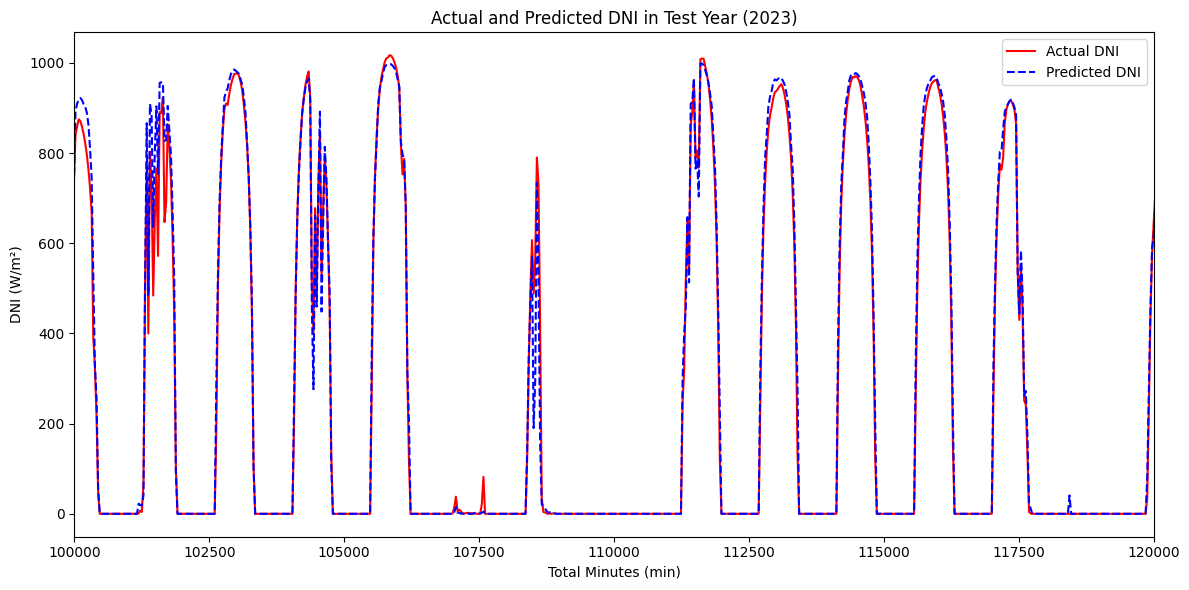

In [ ]:
# Calculate total minutes for the test file (all points, including nighttime)
total_minutes_test = calculate_total_minutes(
    test_file['Year'].values, test_file['Month'].values, test_file['Day'].values,
    test_file['Hour'].values, test_file['Minute'].values)
total_minutes_test = total_minutes_test - total_minutes_test.min()

# Create arrays for all points (filling nighttime with zeros)
test_daytime_mask = theta_z[-len(test_file):] < 90  # Sun is above horizon
test_dni_all = np.zeros(len(test_file))
pred_dni_all = np.zeros(len(test_file))

# Fill in the daytime values
daytime_indices = np.where(test_daytime_mask)[0]
test_dni_all[daytime_indices] = y_test
pred_dni_all[daytime_indices] = y_pred_sky_models

# Plot actual and predicted DNI (all points, including zeros for nighttime)
plt.figure(figsize=(12, 6))
plt.plot(total_minutes_test, test_dni_all, label="Actual DNI", color="red", linestyle="-")
plt.plot(total_minutes_test, pred_dni_all, label="Predicted DNI", color="blue", linestyle="--")

# Configure plot
plt.xlabel("Total Minutes (min)")
plt.ylabel("DNI (W/m²)")
plt.title("Actual and Predicted DNI in Test Year (2023)")
plt.xlim(100000, 120000)  # You can adjust this range as needed
plt.legend()
plt.tight_layout()
plt.show()


## **Get Output**


Remember to change the location variables if you measure in different location.

In [ ]:
# Location
latitude = 40.65
longitude = -75.38
elevat = 106 # meter

### **Single Output**


In [ ]:
# Example Usage, only edit between the lines
#-------------------------------------------------------------------------------
# Date
year = 2023
month = 4
day = 17
hour = 12
minute = 30
tz_offset = -5

# Environmental factors
GHI = 928
temperature = 18.1
relative_humidity = 44.45
pressure = 989
# ------------------------------------------------------------------------------


# Calculate dew point from the given temperature and humidity
dew_point = dew_point_calculator(temperature, relative_humidity)
print(f"Calculated Dew Point: {dew_point:.2f}°C")

# Basic Calculations
local_time = datetime(year, month, day, hour, minute)
zenith_angle = calculate_solar_zenith_single(local_time, tz_offset, latitude, longitude, elevat)
solar_cos_zenith_angle = np.cos(np.radians(zenith_angle))
G0 = calculate_extraterrestrial_radiation(local_time, tz_offset)

# Calculate clearness index
kt = GHI / (G0 * solar_cos_zenith_angle) if solar_cos_zenith_angle > 0 else 0
kt = min(max(kt, 0), 1)  # Clip to valid range [0, 1]
print(f"Calculated clearness index (Kt): {kt:.2f}")

# Determine which model to use based on sky condition
if kt <= 0.35:
    sky_condition = "Overcast"
    model_to_use = model_overcast
    scaler_to_use = scaler_overcast
elif kt <= 0.70:
    sky_condition = "Partly Cloudy"
    model_to_use = model_partly_cloudy
    scaler_to_use = scaler_partly_cloudy
else:
    sky_condition = "Clear Sky"
    model_to_use = model_clear_sky
    scaler_to_use = scaler_clear_sky

print(f"Sky condition: {sky_condition}")

# Predict using the appropriate sky condition model
new_input_df = pd.DataFrame([[GHI, temperature, dew_point, pressure, kt, solar_cos_zenith_angle, G0]],
                            columns=['GHI', 'Temperature', 'Dew Point', 'Pressure', 'Kt', 'Solar Cos Zenith Angle', 'G0'])
new_input_scaled = scaler_to_use.transform(new_input_df)
predicted_dni = model_to_use.predict(new_input_scaled).flatten()[0]

# Apply physical constraints
max_dni = GHI / solar_cos_zenith_angle if solar_cos_zenith_angle > 0 else 0
predicted_dni = min(max(predicted_dni, 0), max_dni)

print(f"Predicted DNI: {predicted_dni:.2f} W/m²")

Calculated Dew Point: 5.80°C
Calculated clearness index (Kt): 0.80
Sky condition: Clear Sky
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Predicted DNI: 971.71 W/m²


### **Export to Spreadsheet**

In [ ]:
def process_input_csv(input_file_path, output_file_path):
    # Load the input CSV file
    df = pd.read_csv(input_file_path)
    print(f"Loaded {len(df)} rows from {input_file_path}")
    output_df = df.copy()

    # Calculate dew point from temperature and relative humidity
    output_df['Dew Point'] = dew_point_calculator(
        output_df['Temperature'].values,
        output_df['Relative Humidity'].values
    )

    # Calculate total minutes and Reset total minutes to start from zero
    total_minutes = calculate_total_minutes(
        output_df['Year'].values,
        output_df['Month'].values,
        output_df['Day'].values,
        output_df['Hour'].values,
        output_df['Minute'].values
    )

    total_minutes = total_minutes - total_minutes.min()
    output_df['Total Minutes'] = total_minutes

    # Calculate solar zenith angles
    zenith_angles = []
    for _, row in output_df.iterrows():
        local_time = datetime(
            int(row['Year']), int(row['Month']), int(row['Day']),
            int(row['Hour']), int(row['Minute'])
        )
        zenith_angle = calculate_solar_zenith_single(
            local_time, tz_offset=-5,
            latitude=40.65, longitude=-75.38, elevation=106
        )
        zenith_angles.append(zenith_angle)

    output_df['Zenith Angle'] = zenith_angles
    output_df['Solar Cos Zenith Angle'] = np.cos(np.radians(output_df['Zenith Angle']))

    # Calculate G0 (extraterrestrial radiation)
    G0_values = []
    for _, row in output_df.iterrows():
        local_time = datetime(
            int(row['Year']), int(row['Month']), int(row['Day']),
            int(row['Hour']), int(row['Minute'])
        )
        G0 = calculate_extraterrestrial_radiation(local_time, tz_offset=-5)
        G0_values.append(G0)

    output_df['G0'] = G0_values

    # Calculate clearness index (Kt)
    Kt = output_df['GHI'].values / (output_df['G0'].values * output_df['Solar Cos Zenith Angle'].values)
    Kt[np.isinf(Kt)] = 0
    Kt[np.isnan(Kt)] = 0
    Kt = np.clip(Kt, 0, 1)
    output_df['Kt'] = Kt

    # Initialize predicted DNI column with zeros
    output_df['Predicted DNI'] = 0.0
    daytime_mask = output_df['Zenith Angle'] < 90

    if daytime_mask.sum() > 0:
        X_predict = output_df.loc[daytime_mask, ['GHI', 'Temperature', 'Dew Point', 'Pressure', 'Kt', 'Solar Cos Zenith Angle', 'G0']]

        # Predict based on sky condition
        overcast_mask = X_predict['Kt'] <= 0.35
        partly_cloudy_mask = (X_predict['Kt'] > 0.35) & (X_predict['Kt'] <= 0.70)
        clear_sky_mask = X_predict['Kt'] > 0.70

        # Initialize predictions for daytime
        predictions = np.zeros(len(X_predict))

        # Predict using overcast model
        if overcast_mask.sum() > 0:
            X_overcast = X_predict[overcast_mask]
            X_overcast_scaled = scaler_overcast.transform(X_overcast)
            predictions[overcast_mask] = model_overcast.predict(X_overcast_scaled).flatten()

        # Predict using partly cloudy model
        if partly_cloudy_mask.sum() > 0:
            X_partly_cloudy = X_predict[partly_cloudy_mask]
            X_partly_cloudy_scaled = scaler_partly_cloudy.transform(X_partly_cloudy)
            predictions[partly_cloudy_mask] = model_partly_cloudy.predict(X_partly_cloudy_scaled).flatten()

        # Predict using clear sky model
        if clear_sky_mask.sum() > 0:
            X_clear_sky = X_predict[clear_sky_mask]
            X_clear_sky_scaled = scaler_clear_sky.transform(X_clear_sky)
            predictions[clear_sky_mask] = model_clear_sky.predict(X_clear_sky_scaled).flatten()

        # Apply physical constraints
        for i, (ghi, cos_zenith) in enumerate(zip(X_predict['GHI'], X_predict['Solar Cos Zenith Angle'])):
            if cos_zenith > 0:
                max_dni = ghi / cos_zenith
                predictions[i] = min(max(predictions[i], 0), max_dni)
            else:
                predictions[i] = 0

        output_df.loc[daytime_mask, 'Predicted DNI'] = predictions

    # Save to output CSV
    output_df.to_csv(output_file_path, index=False)
    print(f"Saved predictions to {output_file_path}")

    return output_df


In [ ]:
# Example usage
# Replace with your input file path and output file path
input_file_path = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQehY4pvRmOMW0l7KlN0_488PlXPKYcwvlc4eLUX3ZWTilVEA8c6QYC4Y0bNozuHUqBnpDVUl3VECDi/pub?gid=0&single=true&output=csv'

print("Preview of input data:")
input_file = pd.read_csv(input_file_path)
print(f"File shape: {input_file.shape}")
input_file.head()


Preview of input data:
File shape: (997, 9)


,Year,Month,Day,Hour,Minute,GHI,Temperature,Pressure,Relative Humidity
0,2023,1,1,0,30,0,6.1,995,100.00
1,2023,1,1,1,30,0,5.7,996,100.00
2,2023,1,1,2,30,0,5.6,996,99.47
3,2023,1,1,3,30,0,5.6,997,98.32
4,2023,1,1,4,30,0,5.6,997,98.37


In [ ]:
# Replace with your input file path and output file path
output_file_path = 'output_data_with_DNI_predictions.csv'

processed_data = process_input_csv(input_file_path, output_file_path)
print("\nPreview of processed data:")
print(f"File shape: {processed_data.shape}")
processed_data.head()

Loaded 997 rows from https://docs.google.com/spreadsheets/d/e/2PACX-1vQehY4pvRmOMW0l7KlN0_488PlXPKYcwvlc4eLUX3ZWTilVEA8c6QYC4Y0bNozuHUqBnpDVUl3VECDi/pub?gid=0&single=true&output=csv
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Saved predictions to output_data_with_DNI_predictions.csv

Preview of processed data:
File shape: (997, 16)


,Year,Month,Day,Hour,Minute,GHI,Temperature,Pressure,Relative Humidity,Dew Point,Total Minutes,Zenith Angle,Solar Cos Zenith Angle,G0,Kt,Predicted DNI
0,2023,1,1,0,30,0,6.1,995,100.00,6.100000,0,30.746677,0.859436,1413.981805,0.0,0.0
1,2023,1,1,1,30,0,5.7,996,100.00,5.700000,60,30.746677,0.859436,1413.981805,0.0,0.0
2,2023,1,1,2,30,0,5.6,996,99.47,5.523395,120,30.746677,0.859436,1413.981805,0.0,0.0
3,2023,1,1,3,30,0,5.6,997,98.32,5.355932,180,30.746677,0.859436,1413.981805,0.0,0.0
4,2023,1,1,4,30,0,5.6,997,98.37,5.363249,240,30.746677,0.859436,1413.981805,0.0,0.0


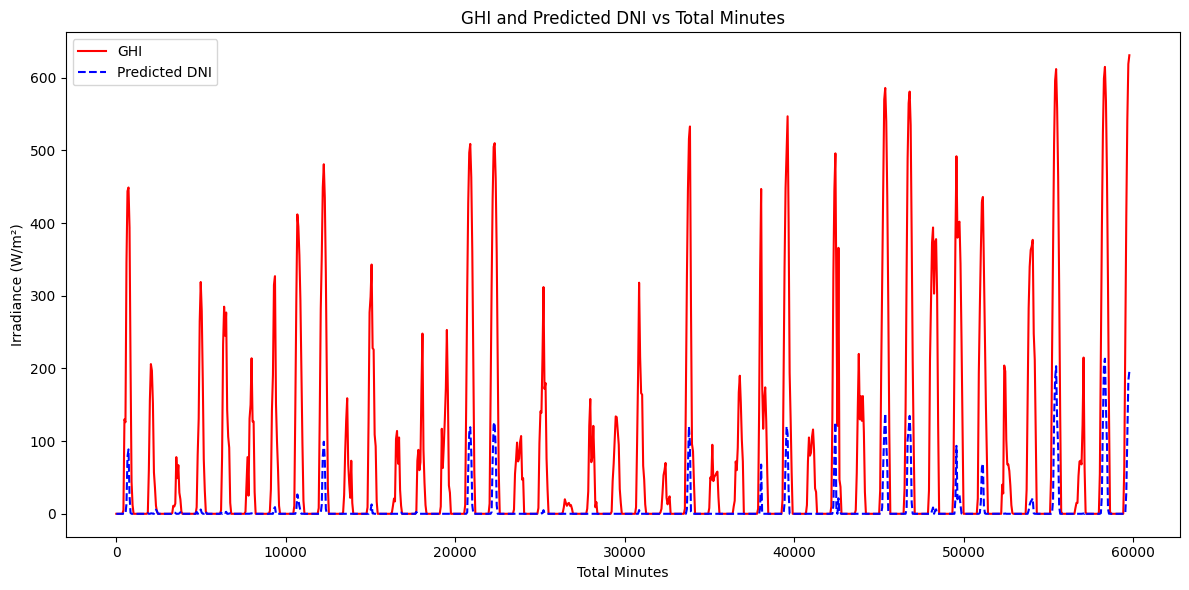

In [ ]:
# Plot Total Minutes vs GHI and Predicted DNI

def plot_results(df):
    plt.figure(figsize=(12, 6))

    plt.plot(df['Total Minutes'], df['GHI'], color='red', label='GHI')
    plt.plot(df['Total Minutes'], df['Predicted DNI'], color='blue', linestyle='--', label='Predicted DNI')

    # Configure plot
    plt.xlabel('Total Minutes')
    plt.ylabel('Irradiance (W/m²)')
    plt.title('GHI and Predicted DNI vs Total Minutes')
    plt.legend()
    plt.tight_layout()

    # Save the plot
    # plt.savefig('irradiance_prediction_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create and save the plot
plot_results(processed_data)

## **Reference**

1. Sandia National Laboratories, Earth, Energy, & Environmental Science PV Performance Modeling Collaborative (PVPMC) Links: https://pvpmc.sandia.gov/modeling-guide/1-weather-design-inputs/irradiance-insolation/global-horizontal-irradiance/

2. Sokol Dervishi, Ardeshir Mahdavi, (2012) Computing diffuse fraction of global horizontal solar radiation: A model comparison,Solar Energy, Volume 86, Issue 6, 2012.

3. D.T. Reindl, W.A. Beckman, J.A. Duffie, (1990)
Diffuse fraction correlations,
Solar Energy,
Volume 45, Issue 1,
1990,
Pages 1-7,
ISSN 0038-092X,
https://doi.org/10.1016/0038-092X(90)90060-P.


4. Lee, Hyunjin & Kim, Shin-Young & Yun, Changyeol. (2017). Comparison of Solar Radiation Models to Estimate Direct Normal Irradiance for Korea. Energies. 10. 594. 10.3390/en10050594.

5. X. Wang, P. Chen, L. Wen, B. Xiao, Z. Zhou and H. Peng, (2018) "Prediction of Direct Normal Irradiance using a Novel Multi-model Algorithm," 2018 Chinese Automation Congress (CAC), Xi'an, China, pp. 2265-2269, doi: 10.1109/CAC.2018.8623195.

6. Bill Marion, (2015) A model for deriving the direct normal and diffuse horizontal irradiance from the global tilted irradiance, Solar Energy, Volume 122, Pages 1037-1046,
Links: https://www.osti.gov/servlets/purl/1227196

7. Perez, R., P. Ineichen, E. Maxwell, R. Seals and A. Zelenka, (1992). “Dynamic Global-to-Direct Irradiance Conversion Models”. ASHRAE Transactions-Research Series, pp. 354-369

8. Solcast a DNV company, Irradiance and Weather Data and methodology, How Solcast generates irradiance and weather, Link: datahttps://solcast.com/irradiance-data-methodology

